In [2]:
%matplotlib inline

import pandas as pd
from PIL import Image
import os
import cv2
from matplotlib import pyplot as plt
from torchvision import  transforms

In [3]:
crop_train_parent_folder = '../../data/Car Labelling/Standford Dataset/cropped/train'
crop_test_parent_folder = '../../data/Car Labelling/Standford Dataset/cropped/val'
org_train_parent_folder = '../../data/Car Labelling/Standford Dataset/original/train'
org_test_parent_folder = '../../data/Car Labelling/Standford Dataset/original/val'


print(os.path.exists(crop_train_parent_folder))
print(os.path.exists(crop_test_parent_folder))
print(os.path.exists(org_train_parent_folder))
print(os.path.exists(org_test_parent_folder))

True
True
True
True


In [ ]:
full_file_path = 'c:/Users/joshu_rdnqgbx/Documents/Current Work/Car Recognition Model/data/Car Labelling/Standford Dataset/train/Acura Integra Type R 2001/00128.jpg'
img = Image.open(full_file_path)

In [5]:
# img.show()
# plt.show()


In [5]:
car_folder_test_arr = 'Acura Integra Type R 2001'.split(' ')

In [6]:
print(car_folder_test_arr[0])
print(' '.join(car_folder_test_arr[1:-1]))
print(car_folder_test_arr[-1])

Acura
Integra Type R
2001


In [10]:
data = []

def get_records(parent_folder, split, cropped):

    for car_folder in os.listdir(parent_folder):
        car_info = car_folder.split(' ')
        make = car_info[0]
        model = ' '.join(car_info[1:-1])
        year = car_info[-1]
        for car_image in os.listdir(os.path.join(parent_folder,car_folder)):
            record = [split,cropped,car_image,make,model,year,car_folder]
            data.append(record)

get_records(crop_train_parent_folder,'train', True)
get_records(crop_test_parent_folder,'val', True)
get_records(org_train_parent_folder,'train', False)
get_records(org_test_parent_folder,'val', False)


df = pd.DataFrame(data, columns=['Original_Split','PreCropped','Image', 'Make', 'Model', 'Year','Full_Name'])
df['Make_Encoded'] = df['Make'].astype('category').cat.codes
df['Model_Encoded'] = df['Model'].astype('category').cat.codes
df['Year_Encoded'] = df['Year'].astype('category').cat.codes
df['Full_Name_Encoded'] = df['Full_Name'].astype('category').cat.codes


In [11]:
df.head()

,Original_Split,PreCropped,Image,Make,Model,Year,Full_Name,Make_Encoded,Model_Encoded,Year_Encoded,Full_Name_Encoded
0,train,True,00128.jpg,Acura,Integra Type R,2001,Acura Integra Type R 2001,1,88,7,1
1,train,True,00130.jpg,Acura,Integra Type R,2001,Acura Integra Type R 2001,1,88,7,1
2,train,True,00198.jpg,Acura,Integra Type R,2001,Acura Integra Type R 2001,1,88,7,1
3,train,True,00255.jpg,Acura,Integra Type R,2001,Acura Integra Type R 2001,1,88,7,1
4,train,True,00308.jpg,Acura,Integra Type R,2001,Acura Integra Type R 2001,1,88,7,1


In [12]:
df.Original_Split.value_counts()

Original_Split
train    20306
val      12018
Name: count, dtype: int64

In [13]:
df.PreCropped.value_counts()

PreCropped
False    16185
True     16139
Name: count, dtype: int64

In [14]:
df.to_csv('../../data/Car Labelling/Standford Dataset/df/data_as_df.csv',index=False)

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch


class CustomDataset(Dataset):
    def __init__(self, parent_dir, df, transformations, label, label_descr):
        self.parent_dir = parent_dir
        self.df = df
        self.transformations = transforms.Compose(transformations)
        self.label = label
        self.label_descr = label_descr
        self.class_values = sorted(df[label_descr].unique())
        
    def __len__(self):
        return len(self.df)
    
    def classes(self, idx):
        return self.df[self.label_desc].iloc[idx]

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
                    idx = idx.tolist()

        item = self.df.iloc[idx]
        img_split = os.path.join(self.parent_dir, item.Original_Split)
        img_folder = os.path.join(img_split, item.Full_Name)
        img_path = os.path.join(img_folder, item.Image)
        image = Image.open(img_path)
        tensor_image = self.transformations(image)

        label = item[self.label]

        return tensor_image,label
        

In [18]:
cropped_df = df[df['PreCropped'] == True]
len(cropped_df)

16139

In [47]:
parent_dir = 'c:/Users/joshu_rdnqgbx/Documents/Current Work/Car Recognition Model/data/Car Labelling/Standford Dataset/cropped'

image_size = 384
normalized_mean = [0.485, 0.456, 0.406]
normalized_std = [0.229, 0.224, 0.225]

transformations = []

transformations.append(transforms.Resize((image_size,image_size), interpolation=2))

transformations.append(transforms.ToTensor())
# transformations.append(transforms.Normalize(normalized_mean, normalized_std))


In [62]:
my_dataset = CustomDataset(parent_dir=parent_dir, df = cropped_df, transformations=transformations, label = 'Full_Name_Encoded', label_descr='Full_Name')
train_loader = DataLoader(my_dataset, 
                        batch_size=2, 
                        shuffle=True, 
                        num_workers=0,
                        pin_memory=True)

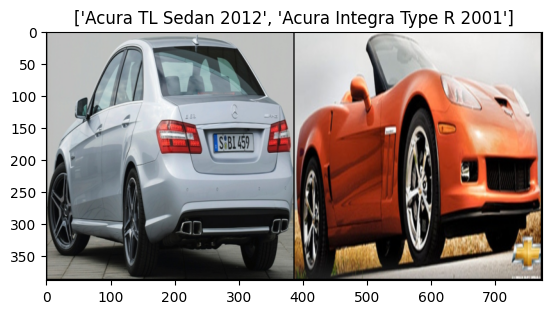

In [60]:
import torchvision
def imshow(inp, title=None):
    """Display image for Tensor."""
    # inp = inp.numpy().transpose((1, 2, 0))
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    # inp = std * inp + mean
    # inp = np.clip(inp, 0, 1)
    # inp = data_transforms['train'](inp.numpy().transpose((1, 2, 0))).T
    plt.imshow(inp.permute(1, 2, 0))
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(train_loader))

# # Make a grid from batch
out = torchvision.utils.make_grid(inputs)

class_names = my_dataset.classes
imshow(out, title=[class_names(x.item()) for x in classes])

In [35]:
def show_image_batch(img_list, title=None):
    num = len(img_list)
    fig = plt.figure()
    for i in range(num):
        ax = fig.add_subplot(1, num, i+1)
        ax.imshow(img_list[i].numpy().transpose([1,2,0]))
        ax.set_title(title[i])

    plt.show()

trainiter = iter(train_loader)
imgs, labels = trainiter.next()

# print(type(imgs), type(labels))
show_image_batch(imgs, title=[my_dataset.classes[x] for x in labels])

AttributeError: '_SingleProcessDataLoaderIter' object has no attribute 'next'

In [ ]:
import numpy as np

In [ ]:
batch_features[0].permute(1, 2, 0).numpy().shape

In [ ]:
cv2.imshow("Image", batch_features[0].permute(1, 2, 0).numpy())
cv2.waitKey(0)

cv2.destroyAllWindows()